# Engine Lifting: minimap2 vs tblastn

Compare coordinate lifting engines against annotated GenBank truth records. Outputs are written to `outputs/`.

## Read This First

This notebook focuses only on lifting accuracy after names have been normalized. It answers three questions:

- Which engine gets coordinates right more often?
- What kinds of failures does each engine produce?
- Which genes/features are hardest for each engine?


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'app').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from app.validation._shared.validation_utils import *

OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

METHOD_COLORS = {'tblastn': '#2f7d4f', 'minimap2': '#4c78a8'}
FAILURE_COLORS = {
    'Correct': '#2f7d4f',
    'Boundary offset': '#75b66b',
    'Wrong coords': '#d6a13d',
    'Alias/name gap': '#8f6bb1',
    'Possible overlap': '#e28e50',
    'Not lifted': '#c44e52',
    'Not in truth': '#7b8794',
}


## Run Both Engines

Each annotated query record is treated as ground truth. The reference annotation is lifted onto that query with both engines, then compared to the query's real annotated features.

In [2]:
from tempfile import TemporaryDirectory
from Bio import SeqIO

from app.src.alignment.minimap_runner import run_minimap2_with_fallback
from app.src.alignment.sam_lifter import build_ref_to_query_map, get_primary_alignment
from app.src.annotation.extractor import extract_all_lifted
from app.src.lifting.tblastn_lifter import lift_all_tblastn

DATASETS = [
    ('PRRS', DATA / 'PRRS_ref_test.gb', CROSS_CHECK / 'PRRS_20seqs.gb'),
    ('FMD', DATA / 'FMD_ref_test.gb', CROSS_CHECK / 'FMD_20seqs.gb'),
]

def run_minimap(ref_features, ref_record, query_record, validate_codons):
    with TemporaryDirectory() as tmp:
        tmp = Path(tmp)
        ref_fa = tmp / 'ref.fa'
        query_fa = tmp / 'query.fa'
        sam_path = tmp / 'alignment.sam'
        SeqIO.write(ref_record, str(ref_fa), 'fasta')
        SeqIO.write(query_record, str(query_fa), 'fasta')
        run_minimap2_with_fallback(ref_fa, query_fa, sam_path, quiet=True)
        aln = get_primary_alignment(sam_path)
        ref_to_query = build_ref_to_query_map(aln)
        return extract_all_lifted(ref_features, query_record, ref_to_query, validate_codons=validate_codons)


In [3]:
all_rows = []
run_rows = []

for virus, ref_path, query_path in DATASETS:
    bundle = load_reference_bundle(ref_path)
    validate_codons = bundle['feature_type'] == 'CDS'
    records = load_genbank_records(query_path)
    run_rows.append({
        'virus': virus,
        'query_records': len(records),
        'ref_feature_type': bundle['feature_type'],
        'ref_features': len(bundle['features']),
    })

    for record in records:
        truth, _ = parse_truth_features(record, bundle['alias_lookup'], bundle['feature_type'])
        if not truth:
            continue

        tblastn_lifted = lift_all_tblastn(bundle['features'], bundle['record'], record, validate_codons=validate_codons)
        minimap_lifted = run_minimap(bundle['features'], bundle['record'], record, validate_codons)

        predictions = []
        predictions.extend(lifted_to_rows(record.id, tblastn_lifted, 'tblastn'))
        predictions.extend(lifted_to_rows(record.id, minimap_lifted, 'minimap2'))

        compared = compare_predictions_to_truth(predictions, truth)
        compared.insert(0, 'virus', virus)
        all_rows.append(compared)

engine_df = pd.concat(all_rows, ignore_index=True)
run_info = pd.DataFrame(run_rows)
engine_df.to_csv(OUTPUT_DIR / 'engine_per_feature.tsv', sep='	', index=False)
run_info.to_csv(OUTPUT_DIR / 'engine_run_info.tsv', sep='	', index=False)
run_info

,virus,query_records,ref_feature_type,ref_features
0,PRRS,20,CDS,9
1,FMD,20,mat_peptide,12


## Headline Accuracy

`coord_pct` is the main metric here: predicted feature coordinates overlap the true same-name feature with IoU >= 0.90.

In [4]:
summary = summarize_comparison(engine_df, ['virus', 'method'])
summary = summary.sort_values(['virus', 'method'])
summary.to_csv(OUTPUT_DIR / 'engine_summary.tsv', sep='	', index=False)

wide = summary.pivot(index='virus', columns='method', values='coord_pct')
wide['tblastn_minus_minimap2'] = (wide['tblastn'] - wide['minimap2']).round(2)
wide.to_csv(OUTPUT_DIR / 'engine_summary_wide.tsv', sep='	')
summary

,virus,method,total,exact,coord_correct,mean_iou,exact_pct,coord_pct
0,FMD,minimap2,240,101,101,0.4565,42.08,42.08
1,FMD,tblastn,240,226,232,0.9698,94.17,96.67
2,PRRS,minimap2,180,53,65,0.4072,29.44,36.11
3,PRRS,tblastn,180,132,150,0.8380,73.33,83.33


method,minimap2,tblastn,tblastn_minus_minimap2
virus,,,
FMD,42.08,96.67,54.59
PRRS,36.11,83.33,47.22


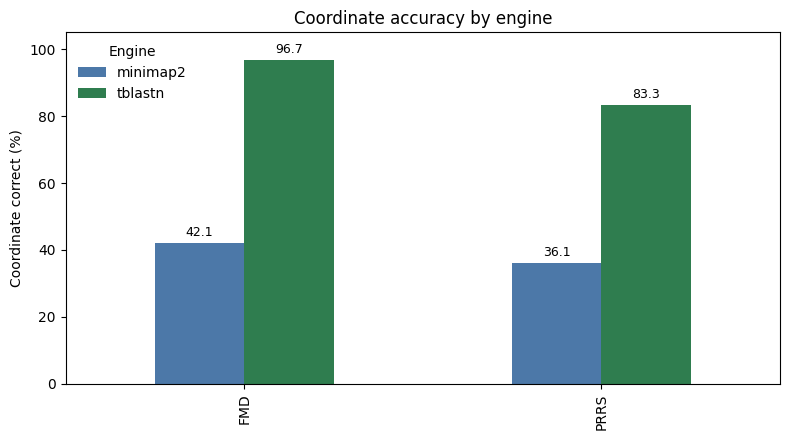

In [5]:
plot_df = summary.pivot(index='virus', columns='method', values='coord_pct')[['minimap2', 'tblastn']]
ax = plot_df.plot(kind='bar', figsize=(8, 4.5), color=[METHOD_COLORS['minimap2'], METHOD_COLORS['tblastn']])
ax.set_ylim(0, 105)
ax.set_ylabel('Coordinate correct (%)')
ax.set_xlabel('')
ax.set_title('Coordinate accuracy by engine')
ax.legend(title='Engine', frameon=False)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=9)

ax.figure.tight_layout()
ax.figure.savefig(OUTPUT_DIR / 'engine_accuracy.png', dpi=180, bbox_inches='tight')
wide

## Failure Modes

This shows whether wrong results are mostly boundary shifts, completely wrong coordinates, or missed lifts.

,virus,method,failure_mode,count,total,pct
2,FMD,minimap2,Not lifted,118,240,49.17
1,FMD,minimap2,Correct,101,240,42.08
3,FMD,minimap2,Wrong coords,20,240,8.33
0,FMD,minimap2,Alias/name gap,1,240,0.42
6,FMD,tblastn,Correct,226,240,94.17
5,FMD,tblastn,Boundary offset,6,240,2.50
8,FMD,tblastn,Wrong coords,5,240,2.08
4,FMD,tblastn,Alias/name gap,2,240,0.83
7,FMD,tblastn,Not lifted,1,240,0.42
13,PRRS,minimap2,Not lifted,66,180,36.67


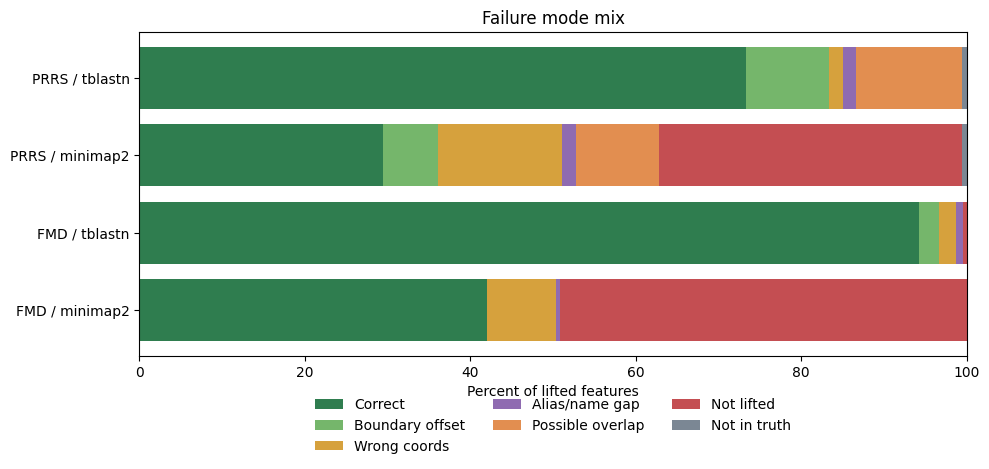

In [6]:
failure_summary = (
    engine_df.groupby(['virus', 'method', 'failure_mode'])
    .size()
    .reset_index(name='count')
)
failure_summary['total'] = failure_summary.groupby(['virus', 'method'])['count'].transform('sum')
failure_summary['pct'] = (failure_summary['count'] / failure_summary['total'] * 100).round(2)
failure_summary.to_csv(OUTPUT_DIR / 'engine_failure_modes.tsv', sep='	', index=False)

failure_order = ['Correct', 'Boundary offset', 'Wrong coords', 'Alias/name gap', 'Possible overlap', 'Not lifted', 'Not in truth']
plot_failure = (
    failure_summary.pivot_table(index=['virus', 'method'], columns='failure_mode', values='pct', fill_value=0)
    .reindex(columns=failure_order, fill_value=0)
)

fig, ax = plt.subplots(figsize=(10, 5))
y_labels = [f'{virus} / {method}' for virus, method in plot_failure.index]
left = pd.Series(0, index=plot_failure.index, dtype=float)
for failure in failure_order:
    values = plot_failure[failure]
    ax.barh(y_labels, values, left=left.values, color=FAILURE_COLORS[failure], label=failure)
    left += values

ax.set_xlim(0, 100)
ax.set_xlabel('Percent of lifted features')
ax.set_ylabel('')
ax.set_title('Failure mode mix')
ax.legend(ncol=3, loc='lower center', bbox_to_anchor=(0.5, -0.34), frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'engine_failure_modes.png', dpi=180, bbox_inches='tight')
failure_summary.sort_values(['virus', 'method', 'count'], ascending=[True, True, False])

## Gene-Level View

This heatmap makes the hard features visible. Rows are virus/gene pairs; columns are engines.

method         minimap2  tblastn
virus feature                   
FMD   2A           45.0     95.0
      2B           50.0    100.0
      2C           50.0    100.0
      3A           45.0    100.0
      3B           35.0     85.0
      3Cpro        40.0     90.0
      3Dpol        45.0    100.0
      Lpro         15.0     90.0
      VP1          45.0    100.0
      VP2          45.0    100.0
      VP3          45.0    100.0
      VP4          45.0    100.0
PRRS  ORF1a         5.0     85.0
      ORF1b        50.0     85.0
      ORF2a        75.0    100.0
      ORF2b         0.0      0.0
      ORF3         40.0    100.0
      ORF4         40.0    100.0
      ORF5         35.0     95.0
      ORF6         35.0     95.0
      ORF7         45.0     90.0

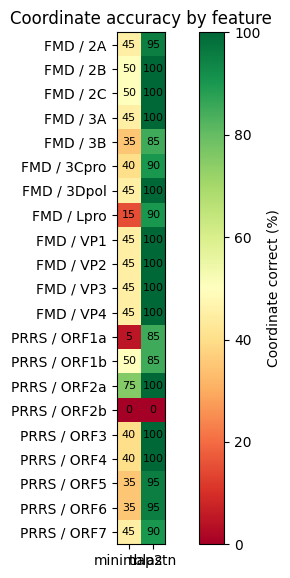

In [7]:
gene_summary = summarize_comparison(engine_df, ['virus', 'pred_name', 'method'])
gene_summary = gene_summary.rename(columns={'pred_name': 'feature'})
gene_summary.to_csv(OUTPUT_DIR / 'engine_by_feature.tsv', sep='	', index=False)

heatmap = gene_summary.pivot_table(
    index=['virus', 'feature'],
    columns='method',
    values='coord_pct',
    fill_value=0,
)[['minimap2', 'tblastn']]

fig, ax = plt.subplots(figsize=(7, max(4.5, 0.28 * len(heatmap))))
im = ax.imshow(heatmap.values, vmin=0, vmax=100, cmap='RdYlGn')
ax.set_xticks(range(len(heatmap.columns)))
ax.set_xticklabels(heatmap.columns)
ax.set_yticks(range(len(heatmap.index)))
ax.set_yticklabels([f'{virus} / {feature}' for virus, feature in heatmap.index])
ax.set_title('Coordinate accuracy by feature')

for i in range(heatmap.shape[0]):
    for j in range(heatmap.shape[1]):
        ax.text(j, i, f'{heatmap.iloc[i, j]:.0f}', ha='center', va='center', fontsize=8)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Coordinate correct (%)')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'engine_feature_heatmap.png', dpi=180, bbox_inches='tight')
heatmap

## Highest-Impact Misses

A compact list of recurring non-correct cases. Start here when deciding what to improve next.

In [8]:
misses = engine_df[engine_df['failure_mode'] != 'Correct'].copy()
miss_summary = (
    misses.groupby(['virus', 'method', 'pred_name', 'failure_mode'])
    .agg(
        count=('record_id', 'size'),
        mean_iou=('iou', 'mean'),
        mean_best_iou=('best_iou', 'mean'),
    )
    .reset_index()
)
miss_summary['mean_iou'] = miss_summary['mean_iou'].round(3)
miss_summary['mean_best_iou'] = miss_summary['mean_best_iou'].round(3)
miss_summary = miss_summary.sort_values(['virus', 'method', 'count'], ascending=[True, True, False])
miss_summary.to_csv(OUTPUT_DIR / 'engine_top_misses.tsv', sep='	', index=False)
miss_summary.groupby(['virus', 'method']).head(8)

,virus,method,pred_name,failure_mode,count,mean_iou,mean_best_iou
6,FMD,minimap2,3B,Not lifted,11,0.000,0.000
9,FMD,minimap2,3Cpro,Not lifted,11,0.000,0.000
12,FMD,minimap2,Lpro,Not lifted,11,0.000,0.000
14,FMD,minimap2,VP1,Not lifted,11,0.000,0.000
15,FMD,minimap2,VP2,Not lifted,11,0.000,0.000
16,FMD,minimap2,VP3,Not lifted,11,0.000,0.000
17,FMD,minimap2,VP4,Not lifted,11,0.000,0.000
0,FMD,minimap2,2A,Not lifted,10,0.000,0.000
18,FMD,tblastn,2A,Boundary offset,4,0.944,0.944
20,FMD,tblastn,3B,Wrong coords,3,0.338,0.338
